In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import load_model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


 100epochrenet.keras				    resnet50_model.h5
 10epochmobilenetv2.keras			    resnet50_model.keras
'Colab Notebooks'				    vgg16model.keras
 Plant_leaf_diseases_dataset_without_augmentation


In [ ]:
data_dir=('/content/drive/MyDrive/Plant_leaf_diseases_dataset_without_augmentation/Plant_leave_diseases_dataset_without_augmentation')

In [ ]:
data_dir

'/content/drive/MyDrive/Plant_leaf_diseases_dataset_without_augmentation/Plant_leave_diseases_dataset_without_augmentation'

In [ ]:
#

if os.path.exists(data_dir):
    print("Connected successfully Dataset found")
else:
    print("Path not found check your folder name again")


Connected successfully Dataset found


In [ ]:
data=ImageDataGenerator(
    rescale=1./255,  #normalized to 0-1
    validation_split=0.2  #20% for validation
)

In [ ]:
Train_data=data.flow_from_directory(
    directory=data_dir,
    batch_size=32,
    target_size=(256,256),
    shuffle=True,
    class_mode='categorical',
    subset='training'

)

validation_data=data.flow_from_directory(
    directory=data_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'

)

Found 44381 images belonging to 39 classes.
Found 11078 images belonging to 39 classes.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


In [ ]:
BASE_DIR = "/content/drive/MyDrive"


In [ ]:
BASE_DIR = "plant_disease_detection"


In [ ]:
ZIP_PATH = "/content/drive/MyDrive/plant_disease_detection_colab_upload.zip"
EXTRACT_DIR = "/content/plant_disease_detection"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Files extracted successfully.")
print(os.listdir(EXTRACT_DIR))


Files extracted successfully.
['Screenshot 2026-04-21 035329.png', 'mobilenet_best.keras', '20epochvgg16model.keras', '100epochrenet.keras', '30eppochefficientnet.keras']


In [ ]:
RESNET_PATH = os.path.join(EXTRACT_DIR, "100epochrenet.keras")
VGG16_PATH = os.path.join(EXTRACT_DIR, "20epochvgg16model.keras")
MOBILENET_PATH = os.path.join(EXTRACT_DIR, "mobilenet_best.keras")
EFFICIENTNET_PATH = os.path.join(EXTRACT_DIR, "30eppochefficientnet.keras")




In [ ]:
# CHANGE ONLY THIS LINE LATER IF YOU WANT TO TEST ANOTHER IMAGE
TEST_IMAGE_PATH = os.path.join(EXTRACT_DIR, "Screenshot 2026-04-21 035329.png")

In [ ]:
class_indices = validation_data.class_indices
class_names = [None] * len(class_indices)

for class_name, class_index in class_indices.items():
    class_names[class_index] = class_name

print("Total classes:", len(class_names))
print(class_names)


Total classes: 39
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomat

In [ ]:
resnet_model = None
vgg16_model = None
mobilenet_model = None
efficientnet_model = None

print("Loading ResNet50...")
try:
    resnet_model = load_model(RESNET_PATH, compile=False)
    print("ResNet50 loaded successfully.")
except Exception as e:
    print("ResNet50 failed:", e)

print("Loading VGG16...")
try:
    vgg16_model = load_model(VGG16_PATH, compile=False)
    print("VGG16 loaded successfully.")
except Exception as e:
    print(f"Error loading VGG16 directly: {e}")
    print("Trying to rebuild VGG16 architecture and load weights...")

    try:
        base_model_vgg16 = VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3)
        )

        vgg16_model = Sequential([
            base_model_vgg16,
            Flatten(),
            Dense(256, activation='relu'),
            Dropout(0.5),
            Dense(len(class_names), activation='softmax')
        ])

        vgg16_model.load_weights(VGG16_PATH)
        print("VGG16 rebuilt and weights loaded successfully.")

    except Exception as e_weights:
        print("VGG16 still failed:", e_weights)
        vgg16_model = None

print("Loading MobileNetV2...")
try:
    mobilenet_model = load_model(MOBILENET_PATH, compile=False)
    print("MobileNetV2 loaded successfully.")
except Exception as e:
    print("MobileNetV2 failed:", e)

print("Loading EfficientNetB0...")
try:
    efficientnet_model = load_model(EFFICIENTNET_PATH, compile=False)
    print("EfficientNetB0 loaded successfully.")
except Exception as e:
    print("EfficientNetB0 failed:", e)

print("\nModel status:")
print("ResNet50:", type(resnet_model))
print("VGG16:", type(vgg16_model))
print("MobileNetV2:", type(mobilenet_model))
print("EfficientNetB0:", type(efficientnet_model))


Loading ResNet50...
ResNet50 loaded successfully.
Loading VGG16...
Error loading VGG16 directly: Exception encountered when calling Flatten.call().

'list' object has no attribute 'shape'

Arguments received by Flatten.call():
  • args=(['<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2487>'],)
  • kwargs=<class 'inspect._empty'>
Trying to rebuild VGG16 architecture and load weights...
VGG16 rebuilt and weights loaded successfully.
Loading MobileNetV2...
MobileNetV2 loaded successfully.
Loading EfficientNetB0...
EfficientNetB0 loaded successfully.

Model status:
ResNet50: <class 'keras.src.models.functional.Functional'>
VGG16: <class 'keras.src.models.sequential.Sequential'>
MobileNetV2: <class 'keras.src.models.functional.Functional'>
EfficientNetB0: <class 'keras.src.models.functional.Functional'>


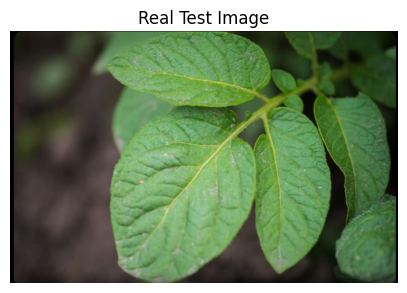

In [ ]:
img = image.load_img(TEST_IMAGE_PATH)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Real Test Image")
plt.show()


In [ ]:
def predict_single_image(model, img_path, model_name, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(predictions))
    predicted_class = class_names[predicted_index]
    confidence = float(predictions[predicted_index] * 100)

    top3_indices = predictions.argsort()[-3:][::-1]
    top3 = []

    for rank, idx in enumerate(top3_indices, start=1):
        top3.append({
            "Model": model_name,
            "Rank": rank,
            "Predicted Class": class_names[idx],
            "Confidence (%)": float(predictions[idx] * 100)
        })

    return predicted_class, confidence, top3


In [ ]:
final_results = []
top3_results = []

models_to_test = [
    ("ResNet50", resnet_model, (256, 256)),
    ("VGG16", vgg16_model, (224, 224)),
    ("MobileNetV2", mobilenet_model, (224, 224)),
    ("EfficientNetB0", efficientnet_model, (224, 224))
]

for model_name, model_obj, target_size in models_to_test:
    predicted_class, confidence, top3 = predict_single_image(
        model=model_obj,
        img_path=TEST_IMAGE_PATH,
        model_name=model_name,
        target_size=target_size
    )

    final_results.append({
        "Model": model_name,
        "Predicted Class": predicted_class,
        "Confidence (%)": confidence
    })

    top3_results.extend(top3)

prediction_df = pd.DataFrame(final_results)
prediction_df["Confidence (%)"] = prediction_df["Confidence (%)"].round(2)

top3_df = pd.DataFrame(top3_results)
top3_df["Confidence (%)"] = top3_df["Confidence (%)"].round(2)


In [ ]:
print("Final prediction from each model:")
display(prediction_df)


Final prediction from each model:


,Model,Predicted Class,Confidence (%)
0,ResNet50,Peach___Bacterial_spot,23.15
1,VGG16,Tomato___Late_blight,99.46
2,MobileNetV2,Tomato___Late_blight,90.68
3,EfficientNetB0,Orange___Haunglongbing_(Citrus_greening),10.74


In [ ]:
print("Top 3 predictions from each model:")
display(top3_df)


Top 3 predictions from each model:


,Model,Rank,Predicted Class,Confidence (%)
0,ResNet50,1,Peach___Bacterial_spot,23.15
1,ResNet50,2,Corn___Common_rust,20.19
2,ResNet50,3,Tomato___Late_blight,18.92
3,VGG16,1,Tomato___Late_blight,99.46
4,VGG16,2,Background_without_leaves,0.32
5,VGG16,3,Potato___Late_blight,0.11
6,MobileNetV2,1,Tomato___Late_blight,90.68
7,MobileNetV2,2,Background_without_leaves,6.06
8,MobileNetV2,3,Potato___Late_blight,2.61
9,EfficientNetB0,1,Orange___Haunglongbing_(Citrus_greening),10.74


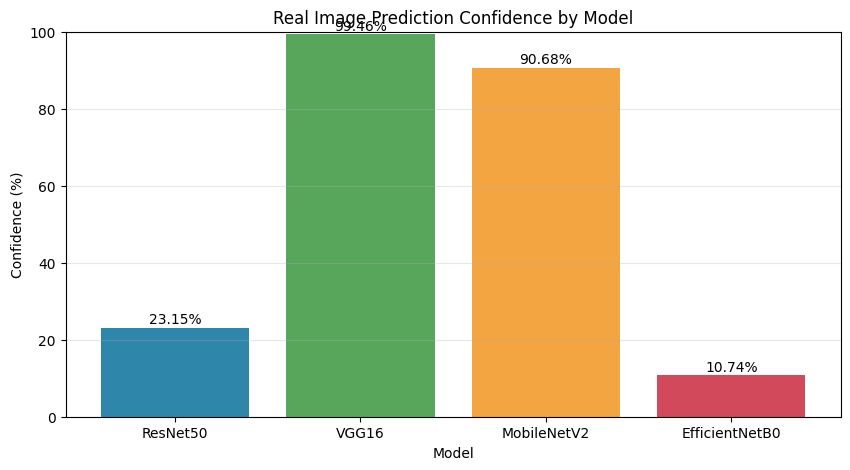

In [ ]:
plt.figure(figsize=(10, 5))

colors = ["#2E86AB", "#58A55C", "#F2A541", "#D1495B"]

bars = plt.bar(
    prediction_df["Model"],
    prediction_df["Confidence (%)"],
    color=colors
)

plt.title("Real Image Prediction Confidence by Model")
plt.xlabel("Model")
plt.ylabel("Confidence (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()


In [ ]:
print("REAL IMAGE TEST SUMMARY")

for _, row in prediction_df.iterrows():
    print(
        f"{row['Model']} predicted '{row['Predicted Class']}' "
        f"with {row['Confidence (%)']}% confidence."
    )

best_prediction = prediction_df.loc[prediction_df["Confidence (%)"].idxmax()]

print("\nMost confident model:")
print(
    f"{best_prediction['Model']} predicted '{best_prediction['Predicted Class']}' "
    f"with {best_prediction['Confidence (%)']}% confidence."
)


========== REAL IMAGE TEST SUMMARY ==========
ResNet50 predicted 'Peach___Bacterial_spot' with 23.15% confidence.
VGG16 predicted 'Tomato___Late_blight' with 99.46% confidence.
MobileNetV2 predicted 'Tomato___Late_blight' with 90.68% confidence.
EfficientNetB0 predicted 'Orange___Haunglongbing_(Citrus_greening)' with 10.74% confidence.

Most confident model:
VGG16 predicted 'Tomato___Late_blight' with 99.46% confidence.
